<a href="https://colab.research.google.com/github/AP24110010586-U/ML/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 4. Before You Start — Set Your Own Seed


In [ ]:
ROLL_NUMBER = 86

print(f"Using random seed = {ROLL_NUMBER}")

Using random seed = 86


## 5. Import Libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else None

## 6. Load and Explore the Iris Dataset

In [ ]:
iris = load_iris()

X = iris.data                     # features: sepal/petal length & width
y = iris.target                   # target: 0 = setosa, 1 = versicolor, 2 = virginica
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]

print("Shape of dataset:", df.shape)
print("\nClass distribution:")
print(df['species'].value_counts())

df.head(10)

Shape of dataset: (150, 5)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


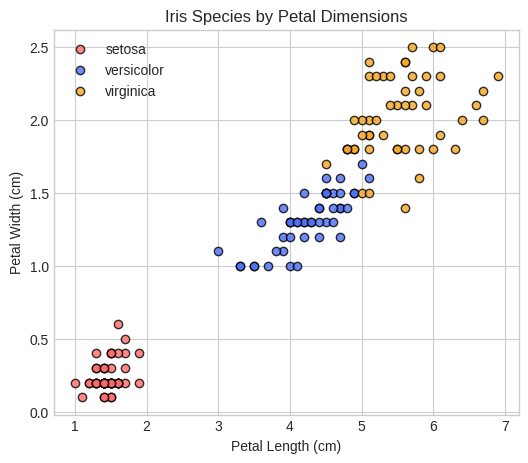

In [ ]:

X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names                                                       #AP24110010586

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]

plt.figure(figsize=(6, 5))
colors = ['#FF6B6B', '#4C6EF5', '#F5A623']
for i, species in enumerate(target_names):
    subset = df[df['species'] == species]
    plt.scatter(subset['petal length (cm)'], subset['petal width (cm)']
,                label=species, color=colors[i], edgecolor='k', alpha=0.8)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Species by Petal Dimensions')
plt.legend()
plt.show()

## 7. Train-Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=ROLL_NUMBER, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Training samples: 105
Testing samples : 45


## 8. Worked Example — Classifying One Flower by Hand

In [ ]:
sample = X_test[0]
true_label = target_names[y_test[0]]
distances = np.sqrt(np.sum((X_train - sample) ** 2, axis=1))
k = 1
nearest_idx = np.argsort(distances)[:k]
nearest_labels = [target_names[y_train[i]] for i in nearest_idx]

print("Test flower measurements:", dict(zip(feature_names, sample.round(2))))
print("True species:", true_label)
print(f"\n{k} nearest neighbours' species:", nearest_labels)

from collections import Counter
vote = Counter(nearest_labels).most_common(1)[0][0]
print(f"\nMajority vote prediction: {vote}")
print("Correct!" if vote == true_label else "Incorrect!")

Test flower measurements: {'sepal length (cm)': np.float64(4.5), 'sepal width (cm)': np.float64(2.3), 'petal length (cm)': np.float64(1.3), 'petal width (cm)': np.float64(0.3)}
True species: setosa

1 nearest neighbours' species: [np.str_('setosa')]

Majority vote prediction: setosa
Correct!


In [ ]:
sample = X_test[0]
true_label = target_names[y_test[0]]
distances = np.sqrt(np.sum((X_train - sample) ** 2, axis=1))
k = 3
nearest_idx = np.argsort(distances)[:k]
nearest_labels = [target_names[y_train[i]] for i in nearest_idx]

print("Test flower measurements:", dict(zip(feature_names, sample.round(2))))
print("True species:", true_label)
print(f"\n{k} nearest neighbours' species:", nearest_labels)

from collections import Counter
vote = Counter(nearest_labels).most_common(1)[0][0]
print(f"\nMajority vote prediction: {vote}")
print("Correct!" if vote == true_label else "Incorrect!")

Test flower measurements: {'sepal length (cm)': np.float64(4.5), 'sepal width (cm)': np.float64(2.3), 'petal length (cm)': np.float64(1.3), 'petal width (cm)': np.float64(0.3)}
True species: setosa

3 nearest neighbours' species: [np.str_('setosa'), np.str_('setosa'), np.str_('setosa')]

Majority vote prediction: setosa
Correct!


In [ ]:
sample = X_test[0]
true_label = target_names[y_test[0]]
distances = np.sqrt(np.sum((X_train - sample) ** 2, axis=1))
k = 9
nearest_idx = np.argsort(distances)[:k]
nearest_labels = [target_names[y_train[i]] for i in nearest_idx]

print("Test flower measurements:", dict(zip(feature_names, sample.round(2))))           #AP24110010586
print("True species:", true_label)
print(f"\n{k} nearest neighbours' species:", nearest_labels)

from collections import Counter
vote = Counter(nearest_labels).most_common(1)[0][0]
print(f"\nMajority vote prediction: {vote}")
print("Correct!" if vote == true_label else "Incorrect!")

Test flower measurements: {'sepal length (cm)': np.float64(4.5), 'sepal width (cm)': np.float64(2.3), 'petal length (cm)': np.float64(1.3), 'petal width (cm)': np.float64(0.3)}
True species: setosa

9 nearest neighbours' species: [np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa')]

Majority vote prediction: setosa
Correct!


## 9. Building the KNN Classifier with scikit-learn

In [ ]:
knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Predictions generated for", len(y_pred), "test samples.")

Predictions generated for 45 test samples.


In [ ]:
knn = KNeighborsClassifier(n_neighbors=3, metric='manhattan')
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Predictions generated for", len(y_pred), "test samples.")

Predictions generated for 45 test samples.


In [ ]:
knn = KNeighborsClassifier(n_neighbors=9, metric='manhattan')
knn.fit(X_train, y_train)                                                                              #AP24110010586

y_pred = knn.predict(X_test)

print("Predictions generated for", len(y_pred), "test samples.")

Predictions generated for 45 test samples.


10. Printing Correct and Wrong Predictions

In [ ]:
results = pd.DataFrame(X_test, columns=feature_names)
results['Actual']    = [target_names[i] for i in y_test]
results['Predicted'] = [target_names[i] for i in y_pred]
results['Result']    = np.where(results['Actual'] == results['Predicted'], 'Correct', 'Wrong')

correct = results[results['Result'] == 'Correct'].reset_index(drop=True)
wrong   = results[results['Result'] == 'Wrong'].reset_index(drop=True)

print("=" * 70)
print(f"CORRECT PREDICTIONS ({len(correct)} out of {len(results)})")
print("=" * 70)
print(correct.to_string(index=True))

print("\n" + "=" * 70)
print(f"WRONG PREDICTIONS ({len(wrong)} out of {len(results)})")
print("=" * 70)
if len(wrong) > 0:
    print(wrong.to_string(index=True))
else:
    print("None — every test sample was classified correctly for this split/seed.")

CORRECT PREDICTIONS (42 out of 45)
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)      Actual   Predicted   Result
0                 4.5               2.3                1.3               0.3      setosa      setosa  Correct
1                 6.1               2.8                4.7               1.2  versicolor  versicolor  Correct
2                 4.8               3.0                1.4               0.1      setosa      setosa  Correct
3                 4.7               3.2                1.6               0.2      setosa      setosa  Correct
4                 6.3               3.3                4.7               1.6  versicolor  versicolor  Correct
5                 7.7               2.8                6.7               2.0   virginica   virginica  Correct
6                 4.8               3.1                1.6               0.2      setosa      setosa  Correct
7                 5.5               2.6                4.4               1.2  versico

versicolor and virginica are similar because of their flower measurements and petal length that makes them harder to distinguish

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)\n")

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=[f"Actual {n}" for n in target_names],
                          columns=[f"Pred {n}" for n in target_names])
print(cm_df)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.9333  (93.33%)

Confusion Matrix:
                   Pred setosa  Pred versicolor  Pred virginica
Actual setosa               15                0               0
Actual versicolor            0               13               2
Actual virginica             0                1              14

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.93      0.87      0.90        15
   virginica       0.88      0.93      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



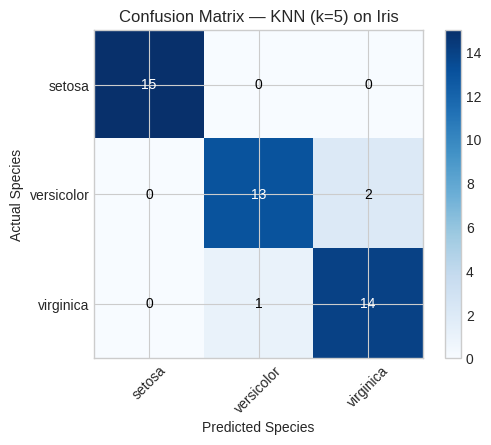

In [ ]:
plt.figure(figsize=(5.5, 4.5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix — KNN (k=5) on Iris')
plt.colorbar()
tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                  color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

## 12. How Does Accuracy Change with k?

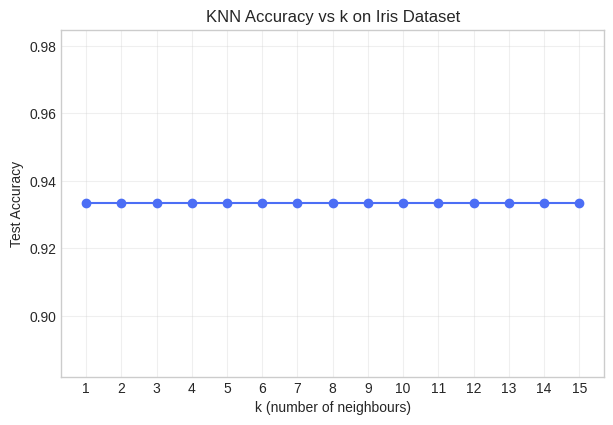

Best k for this split: 1  (Accuracy: 0.9333)


In [ ]:
k_values = range(1, 16)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    accuracies.append(acc)

plt.figure(figsize=(7, 4.5))
plt.plot(list(k_values), accuracies, marker='o', color='#4C6EF5')
plt.xlabel('k (number of neighbours)')
plt.ylabel('Test Accuracy')
plt.title('KNN Accuracy vs k on Iris Dataset')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

best_k = list(k_values)[int(np.argmax(accuracies))]
print(f"Best k for this split: {best_k}  (Accuracy: {max(accuracies):.4f})")

In [ ]:
for k in [1, 3, 9]:

    knn_manhattan = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    knn_manhattan.fit(X_train, y_train)
    y_pred_manhattan = knn_manhattan.predict(X_test)

    print("K =", k)
    print("Wrong predictions:", (y_pred_manhattan != y_test).sum())
    print("Accuracy:", accuracy_score(y_test, y_pred_manhattan))


K = 1
Wrong predictions: 3
Accuracy: 0.9333333333333333
K = 3
Wrong predictions: 3
Accuracy: 0.9333333333333333
K = 9
Wrong predictions: 3
Accuracy: 0.9333333333333333


13. Lab Exercise (To Be Completed by Students)

1.Re-run the notebook with your own roll number as the seed (Section 4) — do NOT use 42.

2.Try k = 1, k = 3, and k = 9. How does the number of wrong predictions change?

3.Change the metric parameter of KNeighborsClassifier from 'euclidean' to 'manhattan'. Does accuracy change?

4.In Section 10, look at your wrong predictions (if any). Which two species are most often confused with each other, and why do you think that happens (hint: look at the confusion matrix)?

In [ ]:
#1.
ROLL_NUMBER = 86

print(f"Using random seed = {ROLL_NUMBER}")

Using random seed = 86


for k=1 wrong predictions=2

for k=3 rong predictions=2

for k=9 rong predictions=1

In [ ]:
for k in [1, 3, 9]:

    knn_manhattan = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    knn_manhattan.fit(X_train, y_train)
    y_pred_manhattan = knn_manhattan.predict(X_test)

    print("K =", k)
    print("Wrong predictions:", (y_pred_manhattan != y_test).sum())
    print("Accuracy:", accuracy_score(y_test, y_pred_manhattan))


K = 1
Wrong predictions: 3
Accuracy: 0.9333333333333333
K = 3
Wrong predictions: 3
Accuracy: 0.9333333333333333
K = 9
Wrong predictions: 3
Accuracy: 0.9333333333333333


versicolor and virginica are similar because of their flower measurements and petal length that makes them harder to distinguish